In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")
%matplotlib inline

In [4]:
REQUIRED_COLUMNS = ["Transaction ID", "Date", "User ID", "Book Title", "Genre", "Borrowing Duration (Days)"]

class LibraryDashboard:
    def __init__(self, output_dir="output_charts"):
        self.raw_data = None
        self.data = None
        self.statistics = {}
        self.output_dir = output_dir
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

    def load_data(self, file_path):
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        if not file_path.lower().endswith(".csv"):
            raise ValueError("Invalid file format. Please provide a .csv file.")

        df = pd.read_csv(file_path)
        self.raw_data = df.copy()

        missing_columns = []
        for col in REQUIRED_COLUMNS:
            if col not in df.columns:
                missing_columns.append(col)
        if missing_columns:
            raise ValueError(f"Dataset is missing required columns: {missing_columns}")

        print(f"Loaded {len(df)} raw rows from '{file_path}'.")

        missing_counts = {}
        for col in REQUIRED_COLUMNS:
            n_missing = df[col].isna().sum() + (df[col].astype(str).str.strip() == "").sum()
            if n_missing > 0:
                missing_counts[col] = int(n_missing)
        if missing_counts:
            for col, count in missing_counts.items():
                print(f"   - {col}: {count} missing")
        else:
            print("No missing values detected.")

        duplicate_count = df.duplicated().sum()
        if duplicate_count > 0:
            print(f"Found {duplicate_count} duplicate rows -> will be removed during cleaning.")

        df = self._clean_data(df)
        self.data = df
        print(f"After cleaning: {len(self.data)} valid rows remain.\n")
        return self.data

    def _clean_data(self, df):
        df = df.drop_duplicates().copy()
        df.replace(r"^\s*$", np.nan, regex=True, inplace=True)
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Borrowing Duration (Days)"] = pd.to_numeric(df["Borrowing Duration (Days)"], errors="coerce")
        df = df[(df["Borrowing Duration (Days)"].isna()) | (df["Borrowing Duration (Days)"] > 0)]
        essential = ["Date", "Book Title", "Genre", "Borrowing Duration (Days)", "User ID"]
        df = df.dropna(subset=essential)
        df["Borrowing Duration (Days)"] = df["Borrowing Duration (Days)"].astype(int)
        df.reset_index(drop=True, inplace=True)
        return df

    def calculate_statistics(self):
        if self.data is None:
            raise RuntimeError("No data loaded. Call load_data() first.")
        df = self.data
        durations = df["Borrowing Duration (Days)"].to_numpy()

        stats = {}
        stats["total_transactions"] = len(df)
        stats["unique_users"] = df["User ID"].nunique()
        stats["unique_books"] = df["Book Title"].nunique()
        stats["avg_duration_days"] = float(np.mean(durations))
        stats["std_duration_days"] = float(np.std(durations))
        stats["min_duration_days"] = int(np.min(durations))
        stats["max_duration_days"] = int(np.max(durations))
        stats["median_duration_days"] = float(np.median(durations))
        stats["variance_duration_days"] = float(np.var(durations))
        stats["percentile_25"] = float(np.percentile(durations, 25))
        stats["percentile_75"] = float(np.percentile(durations, 75))

        book_counts = df["Book Title"].value_counts()
        stats["most_borrowed_book"] = book_counts.index[0]
        stats["most_borrowed_book_count"] = int(book_counts.iloc[0])
        stats["top_5_books"] = book_counts.head(5)
        stats["bottom_5_books"] = book_counts.tail(5)

        genre_counts = df["Genre"].value_counts()
        stats["most_popular_genre"] = genre_counts.index[0]
        stats["genre_distribution"] = genre_counts

        df["Day of Week"] = df["Date"].dt.day_name()
        day_counts = df["Day of Week"].value_counts()
        stats["busiest_day"] = day_counts.index[0]
        stats["day_distribution"] = day_counts

        df["Month"] = df["Date"].dt.to_period("M")
        stats["monthly_trend"] = df.groupby("Month").size()
        stats["cumulative_trend"] = stats["monthly_trend"].cumsum()

        stats["avg_duration_by_genre"] = df.groupby("Genre")["Borrowing Duration (Days)"].mean()
        stats["borrowings_per_book"] = book_counts
        stats["frequent_borrowers"] = df["User ID"].value_counts().head(10)
        stats["transactions_per_user"] = df["User ID"].value_counts()

        df["Late Return"] = df["Borrowing Duration (Days)"] > 21
        stats["late_return_count"] = int(df["Late Return"].sum())
        stats["late_return_pct"] = round(100 * df["Late Return"].mean(), 2)
        stats["on_time_count"] = int((~df["Late Return"]).sum())

        stats["genre_month_matrix"] = df.pivot_table(index="Genre", columns="Month", values="Transaction ID", aggfunc="count", fill_value=0)
        stats["correlation_duration_genre"] = df.groupby("Genre")["Borrowing Duration (Days)"].agg(["mean", "std", "count"])

        self.data = df
        self.statistics = stats
        return stats

    def filter_transactions(self, condition=None, genre=None, start_date=None,
                             end_date=None, min_duration=None, max_duration=None):
        if self.data is None:
            raise RuntimeError("No data loaded. Call load_data() first.")
        filtered = self.data.copy()
        if genre is not None:
            filtered = filtered[filtered["Genre"].str.lower() == genre.lower()]
        if start_date is not None:
            filtered = filtered[filtered["Date"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            filtered = filtered[filtered["Date"] <= pd.to_datetime(end_date)]
        if min_duration is not None:
            filtered = filtered[filtered["Borrowing Duration (Days)"] >= min_duration]
        if max_duration is not None:
            filtered = filtered[filtered["Borrowing Duration (Days)"] <= max_duration]
        if condition is not None:
            filtered = filtered[filtered.apply(condition, axis=1)]
        print(f"Filter applied -> {len(filtered)} of {len(self.data)} transactions match.")
        return filtered

    def generate_report(self):
        if not self.statistics:
            self.calculate_statistics()
        s = self.statistics
        lines = []
        lines.append("=" * 60)
        lines.append("        E-LIBRARY DATA INSIGHTS - SUMMARY REPORT")
        lines.append("=" * 60)
        now_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        lines.append(f"Generated: {now_str}")
        lines.append("-" * 60)
        lines.append(f"Total valid transactions : {s['total_transactions']}")
        lines.append(f"Unique users             : {s['unique_users']}")
        lines.append(f"Unique books             : {s['unique_books']}")
        lines.append("")
        lines.append(f"Most borrowed book       : {s['most_borrowed_book']} ({s['most_borrowed_book_count']} borrows)")
        lines.append(f"Most popular genre       : {s['most_popular_genre']}")
        lines.append(f"Busiest day of the week  : {s['busiest_day']}")
        lines.append("")
        lines.append("Borrowing Duration Stats (days):")
        lines.append(f"   Average    : {s['avg_duration_days']:.2f}")
        lines.append(f"   Median     : {s['median_duration_days']:.2f}")
        lines.append(f"   Std Dev    : {s['std_duration_days']:.2f}")
        lines.append(f"   Variance   : {s['variance_duration_days']:.2f}")
        lines.append(f"   25th pct   : {s['percentile_25']:.2f}")
        lines.append(f"   75th pct   : {s['percentile_75']:.2f}")
        lines.append(f"   Min/Max    : {s['min_duration_days']} / {s['max_duration_days']}")
        lines.append("")
        lines.append(f"Late returns (>21 days)  : {s['late_return_count']} ({s['late_return_pct']}% of transactions)")
        lines.append("")
        lines.append("Top 5 Most Borrowed Books:")
        for title, count in s["top_5_books"].items():
            lines.append(f"   - {title}: {count}")
        lines.append("")
        lines.append("Top 10 Frequent Borrowers:")
        for user, count in s["frequent_borrowers"].items():
            lines.append(f"   - {user}: {count} transactions")
        lines.append("")
        lines.append("Average Borrowing Duration by Genre:")
        for genre, avg in s["avg_duration_by_genre"].sort_values(ascending=False).items():
            lines.append(f"   - {genre}: {avg:.1f} days")
        lines.append("=" * 60)

        report_text = "\n".join(lines)
        print(report_text)
        with open(os.path.join(self.output_dir, "summary_report.txt"), "w") as f:
            f.write(report_text)
        return report_text

    def visualize_top_books(self):
        top5 = self.statistics["top_5_books"]
        plt.figure(figsize=(9, 6))
        sns.barplot(x=top5.values, y=top5.index, hue=top5.index, palette="viridis", legend=False)
        plt.title("Top 5 Most Borrowed Books", fontsize=14, fontweight="bold")
        plt.xlabel("Number of Borrows")
        plt.ylabel("Book Title")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "top_5_books_bar_chart.png"), dpi=150)
        plt.show()

    def visualize_monthly_trend(self):
        trend = self.statistics["monthly_trend"]
        plt.figure(figsize=(10, 6))
        plt.plot(trend.index.astype(str), trend.values, marker="o", color="teal", linewidth=2)
        plt.title("Borrowing Trends Over Months", fontsize=14, fontweight="bold")
        plt.xlabel("Month")
        plt.ylabel("Number of Transactions")
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "monthly_trend_line_graph.png"), dpi=150)
        plt.show()

    def visualize_genre_distribution(self):
        genre_dist = self.statistics["genre_distribution"]
        plt.figure(figsize=(8, 8))
        colors = sns.color_palette("Set2", len(genre_dist))
        plt.pie(genre_dist.values, labels=genre_dist.index, autopct="%1.1f%%", startangle=90, colors=colors)
        plt.title("Distribution of Books Borrowed by Genre", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "genre_distribution_pie_chart.png"), dpi=150)
        plt.show()

    def visualize_activity_heatmap(self):
        df = self.data
        pivot = df.pivot_table(index="Day of Week", columns="Month", values="Transaction ID", aggfunc="count", fill_value=0)
        day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        pivot = pivot.reindex(day_order)
        pivot.columns = pivot.columns.astype(str)
        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.5)
        plt.title("Borrowing Activity by Day of Week and Month", fontsize=14, fontweight="bold")
        plt.xlabel("Month")
        plt.ylabel("Day of Week")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "activity_heatmap.png"), dpi=150)
        plt.show()

    def visualize_duration_distribution(self):
        durations = self.data["Borrowing Duration (Days)"]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.histplot(durations, bins=25, kde=True, color="slateblue", ax=axes[0])
        axes[0].axvline(durations.mean(), color="red", linestyle="--", label=f"Mean: {durations.mean():.1f}")
        axes[0].axvline(durations.median(), color="green", linestyle="--", label=f"Median: {durations.median():.1f}")
        axes[0].set_title("Distribution of Borrowing Duration", fontsize=13, fontweight="bold")
        axes[0].set_xlabel("Duration (Days)")
        axes[0].set_ylabel("Frequency")
        axes[0].legend()

        sns.boxplot(x=durations, color="lightseagreen", ax=axes[1])
        axes[1].set_title("Borrowing Duration Boxplot (Outlier View)", fontsize=13, fontweight="bold")
        axes[1].set_xlabel("Duration (Days)")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "duration_distribution.png"), dpi=150)
        plt.show()

    def visualize_duration_by_genre(self):
        df = self.data
        order = df.groupby("Genre")["Borrowing Duration (Days)"].median().sort_values(ascending=False).index
        plt.figure(figsize=(11, 6))
        sns.boxplot(data=df, x="Genre", y="Borrowing Duration (Days)", hue="Genre", order=order, palette="coolwarm", legend=False)
        plt.title("Borrowing Duration Spread by Genre", fontsize=14, fontweight="bold")
        plt.xlabel("Genre")
        plt.ylabel("Duration (Days)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "duration_by_genre_boxplot.png"), dpi=150)
        plt.show()

    def visualize_busiest_days(self):
        day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        day_dist = self.statistics["day_distribution"].reindex(day_order)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=day_dist.index, y=day_dist.values, hue=day_dist.index, palette="magma", legend=False)
        plt.title("Total Transactions by Day of Week", fontsize=14, fontweight="bold")
        plt.xlabel("Day of Week")
        plt.ylabel("Number of Transactions")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "busiest_days_bar_chart.png"), dpi=150)
        plt.show()

    def visualize_top_borrowers(self):
        top_users = self.statistics["frequent_borrowers"]
        plt.figure(figsize=(9, 6))
        sns.barplot(x=top_users.values, y=top_users.index, hue=top_users.index, palette="crest", legend=False)
        plt.title("Top 10 Most Frequent Borrowers", fontsize=14, fontweight="bold")
        plt.xlabel("Number of Transactions")
        plt.ylabel("User ID")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "top_borrowers_bar_chart.png"), dpi=150)
        plt.show()

    def visualize_late_return_breakdown(self):
        late = self.statistics["late_return_count"]
        on_time = self.statistics["on_time_count"]
        plt.figure(figsize=(7, 7))
        plt.pie([on_time, late], labels=["On Time (<=21 days)", "Late (>21 days)"], autopct="%1.1f%%",
                startangle=90, colors=["#66c2a5", "#fc8d62"], explode=(0, 0.08))
        plt.title("On-Time vs Late Returns", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "late_return_breakdown.png"), dpi=150)
        plt.show()

    def visualize_cumulative_trend(self):
        cum = self.statistics["cumulative_trend"]
        plt.figure(figsize=(10, 6))
        plt.fill_between(cum.index.astype(str), cum.values, color="skyblue", alpha=0.4)
        plt.plot(cum.index.astype(str), cum.values, color="steelblue", marker="o", linewidth=2)
        plt.title("Cumulative Borrowings Over Time", fontsize=14, fontweight="bold")
        plt.xlabel("Month")
        plt.ylabel("Cumulative Transactions")
        plt.xticks(rotation=45)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "cumulative_trend.png"), dpi=150)
        plt.show()

    def visualize_genre_month_heatmap(self):
        matrix = self.statistics["genre_month_matrix"].copy()
        matrix.columns = matrix.columns.astype(str)
        plt.figure(figsize=(13, 6))
        sns.heatmap(matrix, cmap="rocket_r", annot=True, fmt="d", linewidths=0.5)
        plt.title("Genre Popularity by Month", fontsize=14, fontweight="bold")
        plt.xlabel("Month")
        plt.ylabel("Genre")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "genre_month_heatmap.png"), dpi=150)
        plt.show()

    def visualize_user_activity_distribution(self):
        counts = self.statistics["transactions_per_user"]
        plt.figure(figsize=(10, 6))
        sns.histplot(counts, bins=20, color="darkorange", kde=False)
        plt.title("Distribution of Transactions per User", fontsize=14, fontweight="bold")
        plt.xlabel("Number of Transactions per User")
        plt.ylabel("Number of Users")
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, "user_activity_distribution.png"), dpi=150)
        plt.show()

    def generate_all_visualizations(self):
        if not self.statistics:
            self.calculate_statistics()
        self.visualize_top_books()
        self.visualize_monthly_trend()
        self.visualize_genre_distribution()
        self.visualize_activity_heatmap()
        self.visualize_duration_distribution()
        self.visualize_duration_by_genre()
        self.visualize_busiest_days()
        self.visualize_top_borrowers()
        self.visualize_late_return_breakdown()
        self.visualize_cumulative_trend()
        self.visualize_genre_month_heatmap()
        self.visualize_user_activity_distribution()

In [5]:
dashboard = LibraryDashboard(output_dir="output_charts")
dashboard.load_data("library_transactions.csv")

Loaded 1522 raw rows from 'library_transactions.csv'.
   - Date: 6 missing
   - Book Title: 9 missing
   - Genre: 8 missing
   - Borrowing Duration (Days): 10 missing
Found 22 duplicate rows -> will be removed during cleaning.
After cleaning: 1467 valid rows remain.



,Transaction ID,Date,User ID,Book Title,Genre,Borrowing Duration (Days)
0,T00437,2025-05-14,U0001,A Century of Silence,History,7
1,T00200,2025-10-26,U0117,Quantum Drift,Science Fiction,7
2,T01489,2025-10-21,U0039,The Vanishing Hour,Mystery,13
3,T00629,2025-03-31,U0095,The Art of Deep Rest,Self-Help,8
4,T01370,2025-06-30,U0042,The Art of Deep Rest,Self-Help,2
...,...,...,...,...,...,...
1462,T01376,2025-05-22,U0022,The Cartographer's Daughter,Fiction,25
1463,T01415,2025-12-19,U0063,The Sorcerer's Apprentice,Fantasy,1
1464,T00112,2025-04-19,U0042,The Vanishing Hour,Mystery,5
1465,T01357,2025-11-28,U0031,Detective Rao's Final Case,Mystery,14


In [6]:
stats = dashboard.calculate_statistics()
stats

{'total_transactions': 1467,
 'unique_users': 120,
 'unique_books': 35,
 'avg_duration_days': 12.955691888207225,
 'std_duration_days': 8.664704826432231,
 'min_duration_days': 1,
 'max_duration_days': 60,
 'median_duration_days': 12.0,
 'variance_duration_days': 75.077109729198,
 'percentile_25': 8.0,
 'percentile_75': 16.0,
 'most_borrowed_book': 'Rising: A Memoir',
 'most_borrowed_book_count': 87,
 'top_5_books': Book Title
 Rising: A Memoir              87
 Crown of Thorned Vines        76
 Detective Rao's Final Case    71
 The Art of Deep Rest          68
 A Century of Silence          67
 Name: count, dtype: int64,
 'bottom_5_books': Book Title
 Beyond the Event Horizon    13
 Rewire Your Mornings        10
 Whispers of the Tide         8
 Shadows on Elm Street        7
 The Last Rune Keeper         7
 Name: count, dtype: int64,
 'most_popular_genre': 'History',
 'genre_distribution': Genre
 History            286
 Biography          264
 Fantasy            195
 Self-Help        

In [7]:
dashboard.data.describe(include="all")

,Transaction ID,Date,User ID,Book Title,Genre,Borrowing Duration (Days),Day of Week,Month,Late Return
count,1467,1467,1467,1467,1467,1467.000000,1467,1467,1467
unique,1467,NaN,120,35,7,NaN,7,12,2
top,T00437,NaN,U0050,Rising: A Memoir,History,NaN,Thursday,2025-12,False
freq,1,NaN,23,87,286,NaN,239,151,1346
mean,NaN,2025-07-10 23:51:09.938650,NaN,NaN,NaN,12.955692,NaN,NaN,NaN
min,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,2025-04-08 00:00:00,NaN,NaN,NaN,8.000000,NaN,NaN,NaN
50%,NaN,2025-07-13 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN
75%,NaN,2025-10-14 00:00:00,NaN,NaN,NaN,16.000000,NaN,NaN,NaN
max,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,60.000000,NaN,NaN,NaN


In [8]:
stats["correlation_duration_genre"]

,mean,std,count
Genre,,,
Biography,13.606061,8.516374,264
Fantasy,12.123077,8.486814,195
Fiction,13.059783,7.854671,184
History,13.003497,8.983610,286
Mystery,13.831395,9.163272,172
Science Fiction,12.394444,8.216686,180
Self-Help,12.462366,9.262606,186


In [9]:
filtered = dashboard.filter_transactions(genre="Fantasy", min_duration=10)
filtered.head()

Filter applied -> 121 of 1467 transactions match.


,Transaction ID,Date,User ID,Book Title,Genre,Borrowing Duration (Days),Day of Week,Month,Late Return
5,T00687,2025-01-29,U0012,Crown of Thorned Vines,Fantasy,13,Wednesday,2025-01,False
27,T00969,2025-04-13,U0076,The Dragon's Ledger,Fantasy,11,Sunday,2025-04,False
41,T00187,2025-11-30,U0085,The Dragon's Ledger,Fantasy,14,Sunday,2025-11,False
42,T01019,2025-05-07,U0030,The Dragon's Ledger,Fantasy,19,Wednesday,2025-05,False
67,T01260,2025-06-19,U0094,Crown of Thorned Vines,Fantasy,13,Thursday,2025-06,False


In [10]:
dashboard.generate_report()

        E-LIBRARY DATA INSIGHTS - SUMMARY REPORT
Generated: 2026-07-18 13:58:05
------------------------------------------------------------
Total valid transactions : 1467
Unique users             : 120
Unique books             : 35

Most borrowed book       : Rising: A Memoir (87 borrows)
Most popular genre       : History
Busiest day of the week  : Thursday

Borrowing Duration Stats (days):
   Average    : 12.96
   Median     : 12.00
   Std Dev    : 8.66
   Variance   : 75.08
   25th pct   : 8.00
   75th pct   : 16.00
   Min/Max    : 1 / 60

Late returns (>21 days)  : 121 (8.25% of transactions)

Top 5 Most Borrowed Books:
   - Rising: A Memoir: 87
   - Crown of Thorned Vines: 76
   - Detective Rao's Final Case: 71
   - The Art of Deep Rest: 68
   - A Century of Silence: 67

Top 10 Frequent Borrowers:
   - U0050: 23 transactions
   - U0083: 21 transactions
   - U0071: 19 transactions
   - U0039: 18 transactions
   - U0012: 18 transactions
   - U0098: 18 transactions
   - U0085: 18 t

"============================================================\n        E-LIBRARY DATA INSIGHTS - SUMMARY REPORT\n============================================================\nGenerated: 2026-07-18 13:58:05\n------------------------------------------------------------\nTotal valid transactions : 1467\nUnique users             : 120\nUnique books             : 35\n\nMost borrowed book       : Rising: A Memoir (87 borrows)\nMost popular genre       : History\nBusiest day of the week  : Thursday\n\nBorrowing Duration Stats (days):\n   Average    : 12.96\n   Median     : 12.00\n   Std Dev    : 8.66\n   Variance   : 75.08\n   25th pct   : 8.00\n   75th pct   : 16.00\n   Min/Max    : 1 / 60\n\nLate returns (>21 days)  : 121 (8.25% of transactions)\n\nTop 5 Most Borrowed Books:\n   - Rising: A Memoir: 87\n   - Crown of Thorned Vines: 76\n   - Detective Rao's Final Case: 71\n   - The Art of Deep Rest: 68\n   - A Century of Silence: 67\n\nTop 10 Frequent Borrowers:\n   - U0050: 23 transactions\n

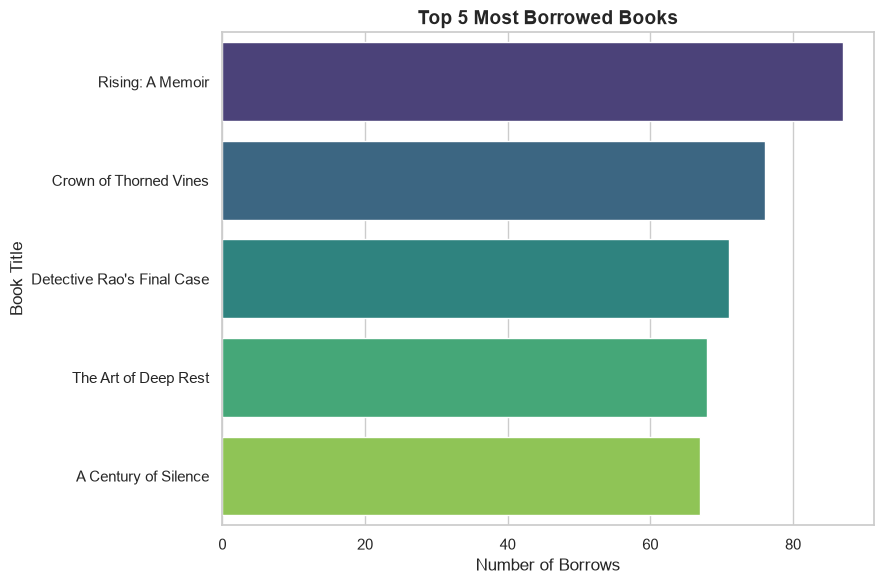

In [11]:
dashboard.visualize_top_books()

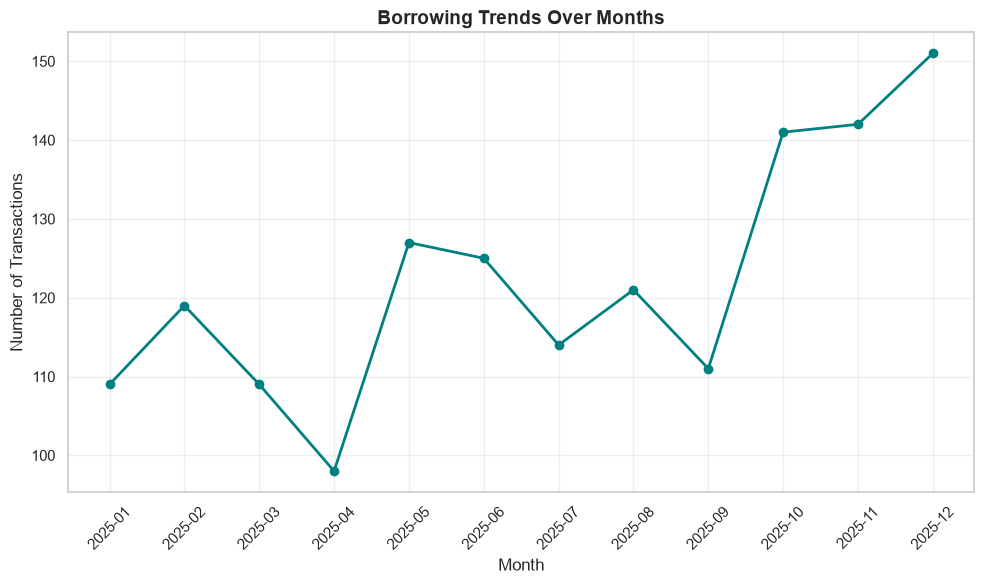

In [12]:
dashboard.visualize_monthly_trend()

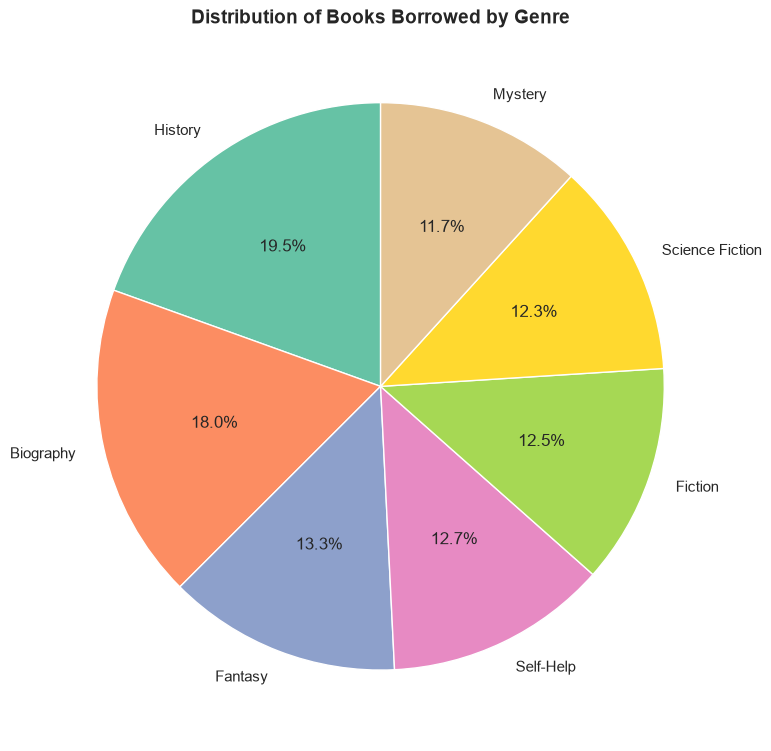

In [13]:
dashboard.visualize_genre_distribution()

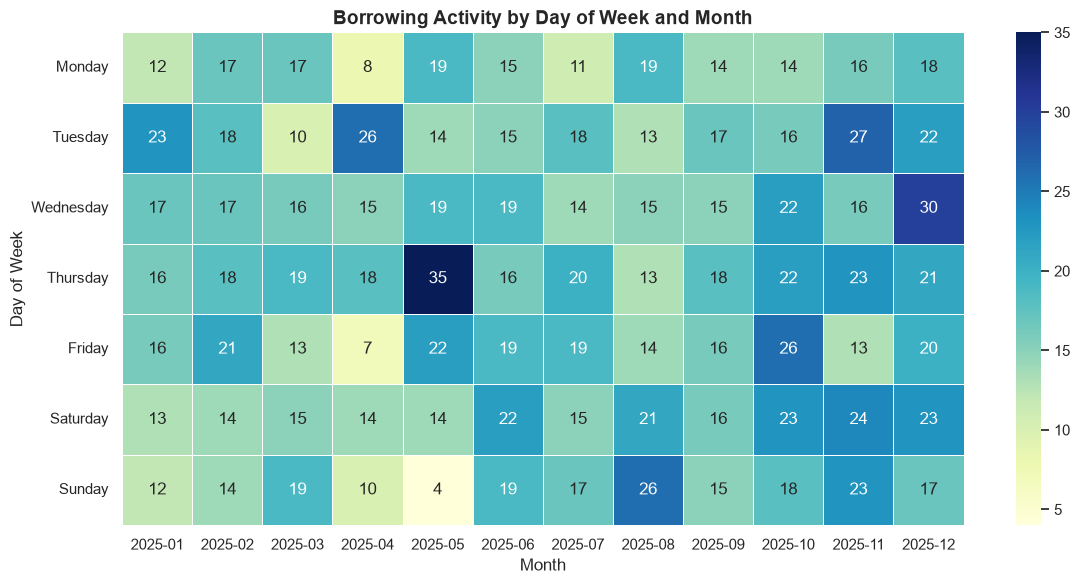

In [14]:
dashboard.visualize_activity_heatmap()

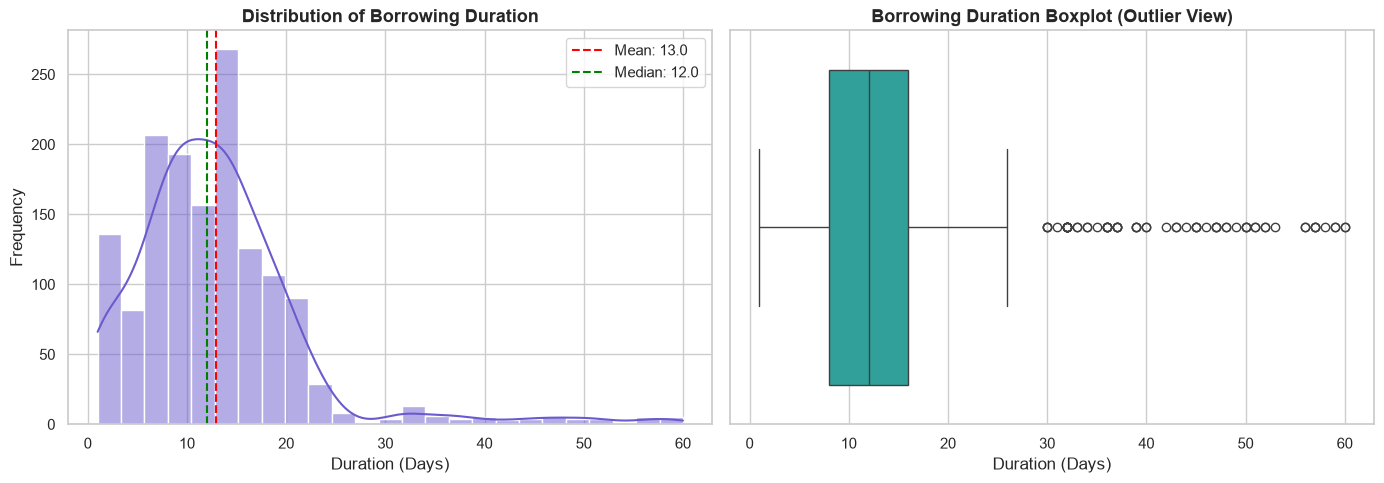

In [15]:
dashboard.visualize_duration_distribution()

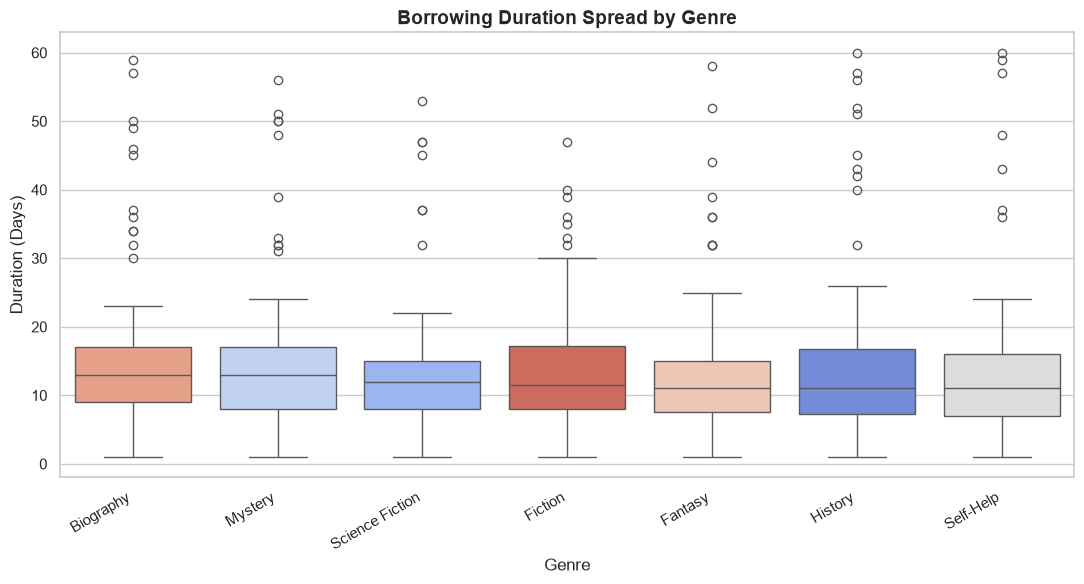

In [16]:
dashboard.visualize_duration_by_genre()

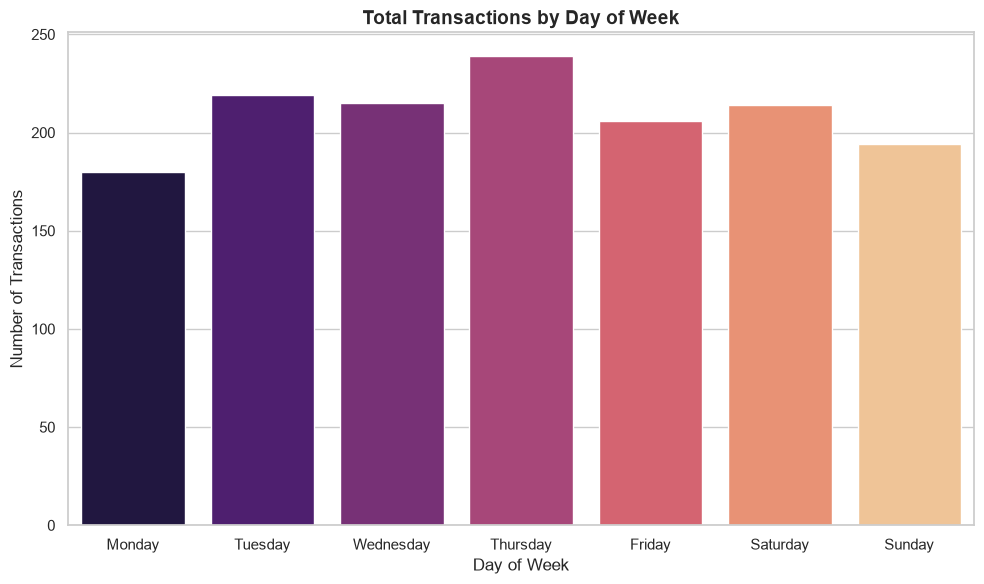

In [17]:
dashboard.visualize_busiest_days()

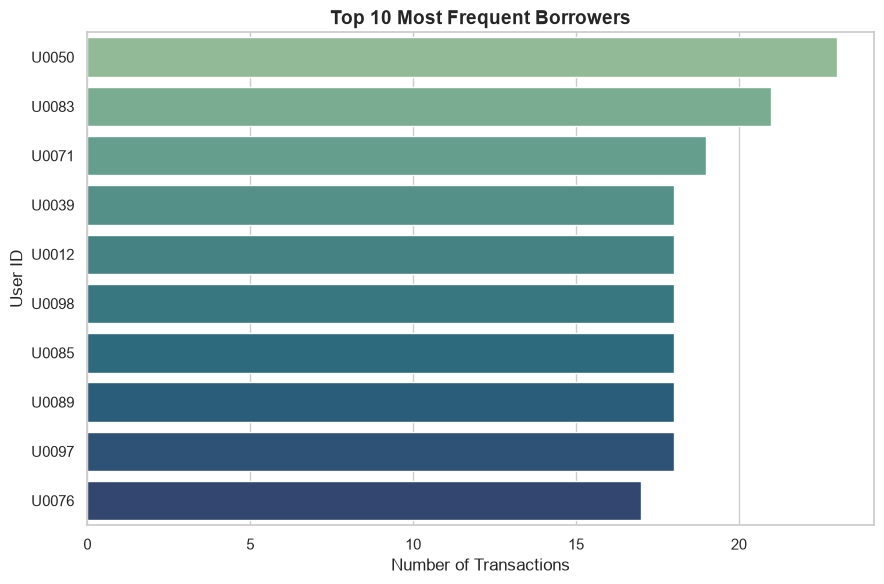

In [18]:
dashboard.visualize_top_borrowers()

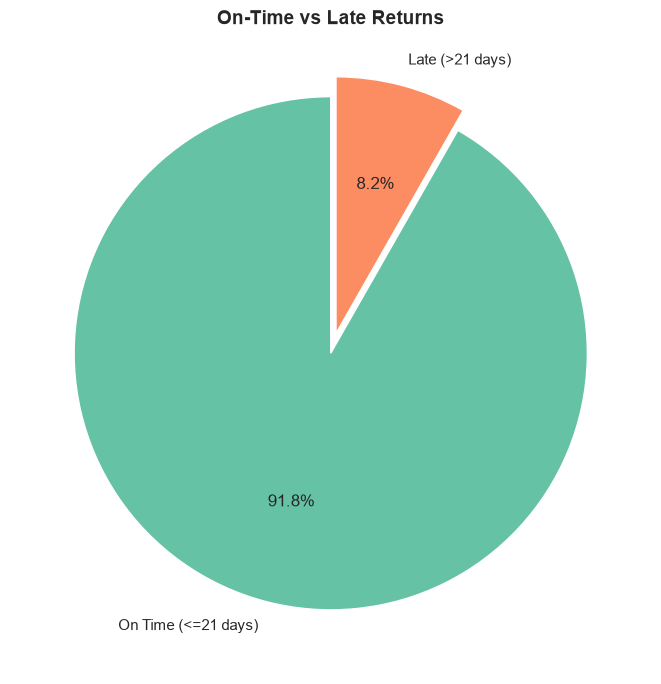

In [19]:
dashboard.visualize_late_return_breakdown()

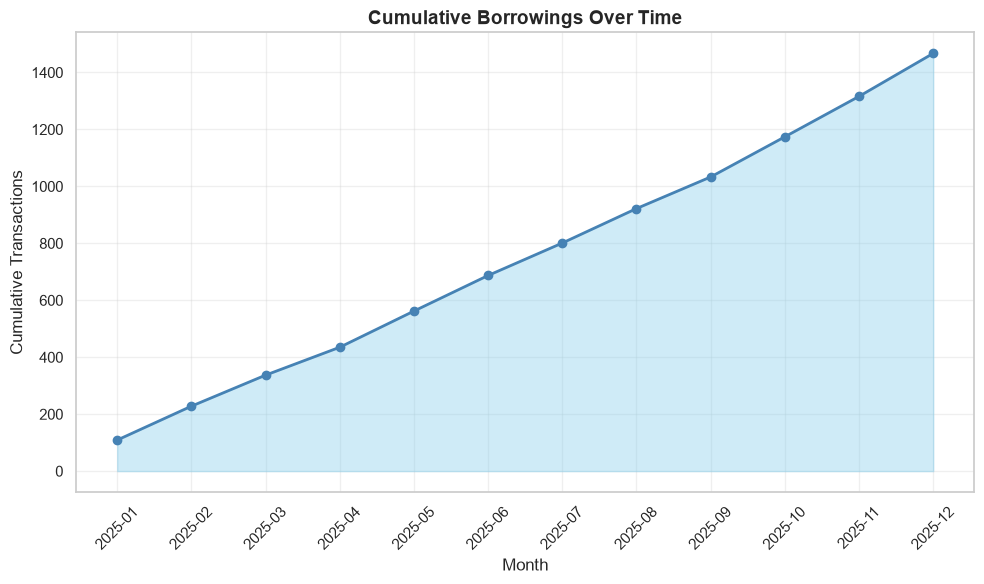

In [20]:
dashboard.visualize_cumulative_trend()

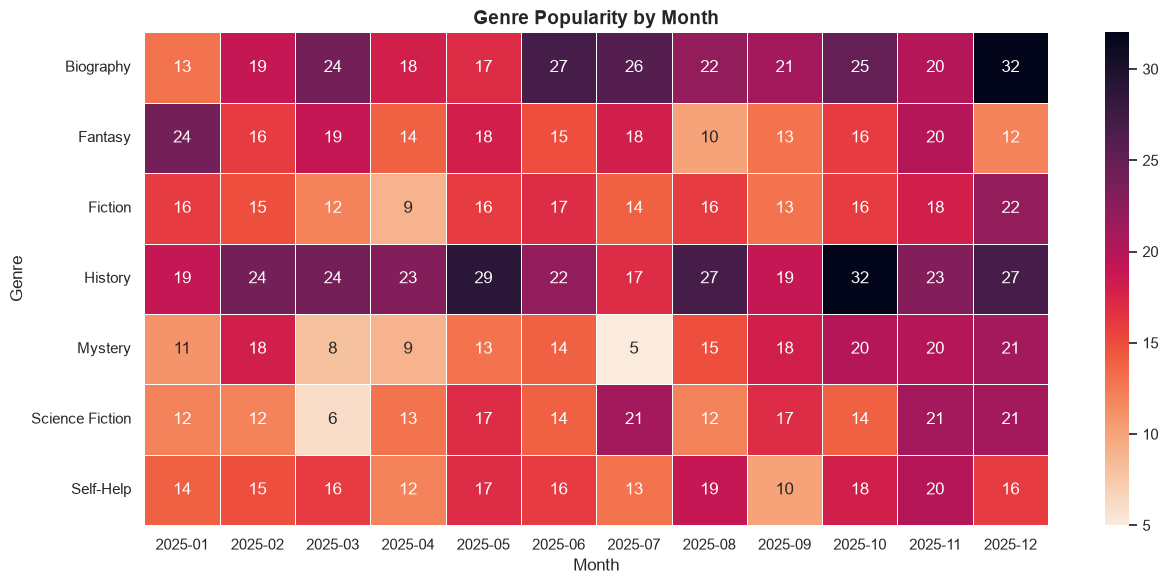

In [21]:
dashboard.visualize_genre_month_heatmap()

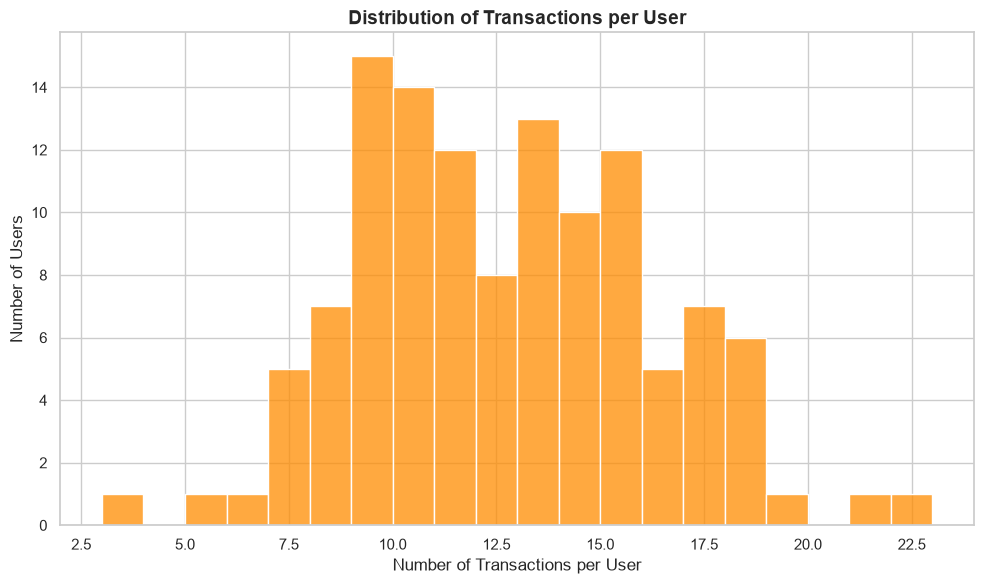

In [22]:
dashboard.visualize_user_activity_distribution()